In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils as nn_utils

import torch.optim as optim
from sklearn.model_selection import train_test_split 
import numpy as np

import matplotlib.pyplot as plt

import datetime 



In [3]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
CROP_IDS = [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8]



cuda:0


In [4]:
def plot_class_distribution(class_percentage):
    """
    Plot the class distribution as a bar chart.
    
    Parameters:
    - class_percentage: dictionary with class IDs as keys and their respective percentage of pixels.
    """
    classes = list(class_percentage.keys())
    percentages = list(class_percentage.values())
    
    plt.bar(classes, percentages, color='b', alpha=0.7)
    plt.xlabel('Class ID')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Class Distribution Across Dataset')
    plt.xticks(classes)  # Ensure all class IDs are labeled on the x-axis
    plt.show()
    
def calculate_overall_class_distribution(labels_dataset, include_no_data=True, show_plot=True):
    """
    Calculate the overall class distribution across all patches in the dataset.
    
    Parameters:
    - labels_dataset: numpy array of shape (num_patches, 64, 64) representing the patches.
    
    Returns:
    - overall_class_percentage: dictionary with the class ID as key and percentage of pixels across all patches.
    """
    if include_no_data:
        overall_class_counts = {i: 0 for i in (set(range(-1, 9)))} # Assuming 10 classes
    else:
        overall_class_counts = {i: 0 for i in range(0, 9)}
    total_pixels = 0

    # Loop through all patches in the dataset
    for labels_patch in labels_dataset:
        flattened_patch = labels_patch.flatten()
        total_pixels += flattened_patch.size
        
        # Count class pixels in the current patch
        class_counts = {i: np.sum(flattened_patch == i) for i in overall_class_counts.keys()}

        for cls, count in class_counts.items():
            overall_class_counts[cls] += count

    # Calculate the percentage for each class across all patches
    overall_class_percentage = {cls: (count / total_pixels) * 100 for cls, count in overall_class_counts.items()}   

    if show_plot:
        plot_class_distribution(overall_class_percentage)
    
    return overall_class_percentage


In [5]:
def remap_labels_for_ce_loss(labels, ignore_index=-1):
    labels = labels.clone().detach()
    mask = (labels != ignore_index)
    labels[mask] -= 1
    return labels


In [6]:
#Load dataset
# agumented_data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/7_augumented_data_64X64_majority60.npy') 
# agumented_labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/8_augumented_labels_64X64_majority60.npy') 

# original_data = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/9_filtered_data_64X64_majority60.npy")
# original_labels = np.load(r"../Dataset/s2-utm-33N-18E-242N-2018/10_filtered_labels_64X64_majority60.npy")

data = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/11_final_gan_data_without_mixed_patches_64X64_majority60.npy')
labels = np.load(r'../Dataset/s2-utm-33N-18E-242N-2018/DS2/12_final_gan_labels_without_mixed_patches_64X64_majority60.npy')

# Update labels to bring the labels in to ranging from 0 to 9
labels_upadated = remap_labels_for_ce_loss(torch.tensor(labels))
print(data.shape)
print(labels.shape)


(4403, 64, 64, 4)
(4403, 64, 64)


min_std = None
min_varience = None
index = None
extreme_diffs = None
extreme_diff_index = None
for i in range(1,1000):
    train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels, test_size=0.2, random_state=i)
    validation_data, test_data, validation_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=2)

    dict_percs = calculate_overall_class_distribution(train_labels, include_no_data= False, show_plot=False)
    values = dict_percs.values()

    std = statistics.variance(values)


    if i%100==0:
        print(i)

    if min_std == None:
        min_std = std
        index = i
    elif std<min_std:
        min_std = std
        index = i

    max_min_diff = max(values)- min(values)
    if extreme_diffs == None:
        extreme_diffs = max_min_diff
        extreme_diff_index = i
    elif max_min_diff<extreme_diffs:
        extreme_diffs = max_min_diff
        extreme_diff_index = i

print(index, min_std) 
print(extreme_diff_index, extreme_diffs)


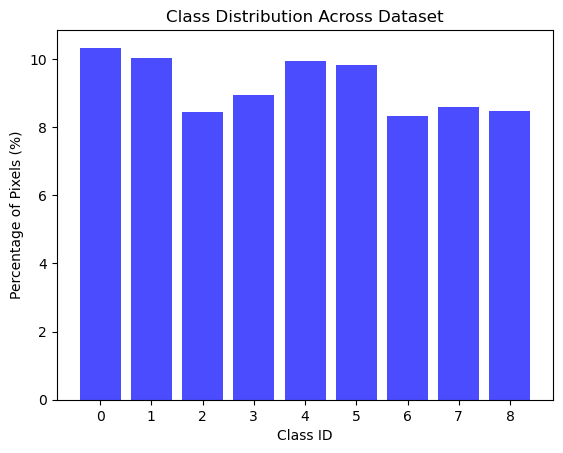

{0: 10.327349461864706,
 1: 10.028682710906445,
 2: 8.442940135221464,
 3: 8.950297904244747,
 4: 9.936606619995741,
 5: 9.824837073218342,
 6: 8.325035879383163,
 7: 8.602068249574106,
 8: 8.485127524311471}

In [7]:
seed_value = 636
train_data, validation_test_data, train_labels, validation_test_labels = train_test_split(data, labels_upadated.cpu().numpy(), test_size=0.2, random_state=seed_value)
validation_data, test_data, validation_labels, test_labels = train_test_split(validation_test_data, validation_test_labels, test_size=0.5, random_state=seed_value)

calculate_overall_class_distribution(train_labels, include_no_data= False)


In [39]:
class PatchEmbeddingGenerator(nn.Module):
    def __init__(self, noise_dim, label_dim, emb_dim, patch_size=8, num_patches=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches  # 8x8 patches for 64x64 images
        
        # Project (noise + label embedding) to patch embeddings sequence
        self.fc = nn.Linear(noise_dim + label_dim, emb_dim * num_patches)
        
    def forward(self, z, labels):
        # z: [B, noise_dim], labels: [B, label_dim]
        x = torch.cat([z, labels], dim=1)
        x = self.fc(x)  # [B, emb_dim * num_patches]
        x = x.view(-1, self.num_patches, x.size(-1) // self.num_patches)  # [B, num_patches, emb_dim]
        return x

class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim=100, label_dim=64*64, emb_dim=512, num_heads=8, num_layers=12, patch_size=8, out_channels=4):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (64 // patch_size) ** 2
        self.out_channels=4
        
        self.patch_embed = PatchEmbeddingGenerator(noise_dim, label_dim, emb_dim, patch_size, self.num_patches)
        
        decoder_layer = nn.TransformerDecoderLayer(d_model=emb_dim, nhead=num_heads, dim_feedforward=emb_dim*4)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        # Positional embedding for patches
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, emb_dim))
        
        # Project embeddings to pixels for each patch
        self.patch_to_pixels = nn.Linear(emb_dim, patch_size * patch_size * out_channels)
        
    def forward(self, z, labels):
        # z: noise vector [B, noise_dim]
        # labels: flattened labels [B, label_dim] (e.g., 64*64)
        
        x = self.patch_embed(z, labels)  # [B, num_patches, emb_dim]
        
        # Add positional embedding
        x = x + self.pos_embed
        
        # Decoder input: typically uses a target sequence, here we can use zeros or learned tokens
        tgt = torch.zeros_like(x)
        
        # Transformer decoder expects shape: [seq_len, batch, emb_dim]
        x = x.transpose(0,1)  # [num_patches, B, emb_dim]
        tgt = tgt.transpose(0,1)
        
        out = self.transformer_decoder(tgt, x)  # [num_patches, B, emb_dim]
        out = out.transpose(0,1)  # [B, num_patches, emb_dim]
        
        # Map patch embeddings to pixels
        patches = self.patch_to_pixels(out)  # [B, num_patches, patch_size*patch_size*out_channels]
        
        # Reshape patches to images
        B = patches.size(0)
        patches = patches.view(B, self.num_patches, self.out_channels, self.patch_size, self.patch_size)
        
        # Rearrange patches into full image: 8x8 patches for 64x64 image
        img = self.combine_patches(patches, grid_size=64//self.patch_size)
        
        # Output range -1 to 1 for tanh
        img = torch.tanh(img)
        
        return img
    
    def combine_patches(self, patches, grid_size):
        # patches: [B, N_patches, C, patch_h, patch_w]
        B, N, C, H, W = patches.size()
        patches = patches.permute(0, 2, 1, 3, 4)  # [B, C, N_patches, H, W]
        patches = patches.contiguous().view(B, C, grid_size, grid_size, H, W)
        patches = patches.permute(0, 1, 2, 4, 3, 5)
        patches = patches.contiguous().view(B, C, grid_size*H, grid_size*W)
        return patches


In [9]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=4, patch_size=8, emb_dim=256):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C=4, 64, 64]
        x = self.proj(x)  # [B, emb_dim, 8, 8]
        x = x.flatten(2)   # [B, emb_dim, 64]
        x = x.transpose(1, 2)  # [B, 64, emb_dim]
        return x

class TransformerDiscriminator(nn.Module):
    def __init__(self, emb_dim=256, num_heads=8, num_layers=8, num_classes=9, patch_size=8):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels=4, patch_size=patch_size, emb_dim=emb_dim)
        self.patch_embed.proj = nn_utils.spectral_norm(self.patch_embed.proj)
        
        self.num_patches = (64 // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, emb_dim))
        self.num_classes = num_classes

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads, dim_feedforward=emb_dim*4)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.norm = nn.LayerNorm(emb_dim)

        # Adversarial output head
        self.adv_head = nn_utils.spectral_norm(nn.Linear(emb_dim, 1))

        # Segmentation head (simple MLP per patch for example)
        self.seg_head = nn_utils.spectral_norm(nn.Linear(emb_dim, self.num_classes))

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)  # [B, N_patches, emb_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, emb_dim]
        x = torch.cat((cls_tokens, x), dim=1)  # [B, 1 + N_patches, emb_dim]
        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.transformer(x)  # [B, 1 + N_patches, emb_dim]
        x = self.norm(x)

        # Adversarial score from CLS token
        real_fake = self.adv_head(x[:, 0])  # [B, 1]

        # Segmentation logits for each patch (skip cls token)
        seg_logits = self.seg_head(x[:, 1:])  # [B, N_patches, num_classes]

        # Optional: reshape seg_logits to spatial map (e.g., 8x8 patches)
        seg_map = seg_logits.transpose(1, 2).view(B, self.num_classes, 8, 8)

        # You may want to upsample seg_map to 64x64 with interpolation or conv layers
        seg_map = nn.functional.interpolate(seg_map, size=(64, 64), mode='bilinear', align_corners=False)

        return real_fake.view(-1), seg_map


In [10]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [ ]:
def load_models(generator, discriminator, g_optimizer, d_optimizer, path):
    checkpoint = torch.load(path, map_location=DEVICE)
    
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

def save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, path, modelid=0):
    epoch+=1

    filename = r'/acgan_checkpoint-Model '+str(modelid)+r'-Epoch '+str(epoch)+r'_'+ str(datetime.date.today()) +r'.pth'
    full_path = path + filename
    print(full_path)

    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'g_optimizer_state_dict': g_optimizer.state_dict(),
        'd_optimizer_state_dict': d_optimizer.state_dict(),
    }, full_path)
    
    print(f"Models saved to {full_path}")


In [ ]:
def hinge_d_loss(real_logits, fake_logits):
    loss_real = torch.mean(torch.relu(1.0 - real_logits))
    loss_fake = torch.mean(torch.relu(1.0 + fake_logits))
    return 0.5 * (loss_real + loss_fake)


def hinge_g_loss(fake_logits):
    return -torch.mean(fake_logits)


def train_acgan_transformer(generator, discriminator, g_optimizer, d_optimizer, dataloader, epochs=10, noise_dim = 100, d_lr=1e-4, g_lr=1e-4, modelid=1):
    losses_g, losses_d = [], []

    auxiliary_loss = nn.CrossEntropyLoss(ignore_index=-1)

    for epoch in range(epochs):
        g_loss_total, d_loss_total = 0, 0

        for real_imgs, real_labels in dataloader:
            real_imgs = real_imgs.to(DEVICE)  # Expect normalized [-1,1]
            real_labels = real_labels.to(DEVICE).long()
            batch_size = real_imgs.size(0)
            
            # Flatten labels for conditioning (if not flattened yet)
            real_labels_flat = real_labels.view(batch_size, -1)  # [B, 64*64]

            # ---------------------
            #  Train Discriminator
            # ---------------------
            d_optimizer.zero_grad()

            real_pred, real_seg = discriminator(real_imgs)
            z = torch.randn(batch_size, noise_dim, device=DEVICE)
            fake_imgs = generator(z, real_labels_flat)
            fake_pred, fake_seg = discriminator(fake_imgs.detach())

            d_adv_loss = hinge_d_loss(real_pred, fake_pred)
            d_aux_loss_real = auxiliary_loss(real_seg, real_labels.long())
            d_aux_loss_fake = auxiliary_loss(fake_seg, real_labels)  # Optional: depends on your setup
            d_aux_loss = (d_aux_loss_real + d_aux_loss_fake) / 2

            d_loss = d_adv_loss + d_aux_loss
            d_loss.backward()
            d_optimizer.step()

            # -----------------
            #  Train Generator
            # -----------------
            g_optimizer.zero_grad()
            gen_pred, gen_seg = discriminator(fake_imgs)
            g_adv_loss = hinge_g_loss(gen_pred)
            g_aux_loss = auxiliary_loss(gen_seg, real_labels)
            g_loss = g_adv_loss + g_aux_loss
            g_loss.backward()
            g_optimizer.step()

            g_loss_total += g_loss.item()
            d_loss_total += d_loss.item()
        
        avg_g = g_loss_total / len(dataloader)
        avg_d = d_loss_total / len(dataloader)
        losses_g.append(avg_g)
        losses_d.append(avg_d)

        print(f"Epoch {epoch+1} | discriminator Loss: {avg_d:.4f} | generator Loss: {avg_g:.4f}")

        if (epoch+1%10)==0:
            save_models(generator, discriminator, g_optimizer, d_optimizer, epoch, modelid=modelid, path=r'../GAN models/Spatial models')
        
    return losses_g, losses_d


In [15]:
def plot_losses(losses_g, losses_d, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(losses_g, label='Generator Loss')
    plt.plot(losses_d, label='Discriminator Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Generator and Discriminator Loss Over Time")
    if save_path:
        plt.savefig(save_path)
    plt.show()

# Save model function
def save_model(model, path):
    torch.save(model.state_dict(), path)


In [13]:
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# Example random dataset
image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

# Assume array2 has shape (N, 64, 64)
#label_data = np.expand_dims(train_labels, axis=1) 

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=16, shuffle=True)


In [47]:
noise_dim = 100

generator = TransformerGenerator(noise_dim=noise_dim, label_dim=64*64).to(DEVICE)
discriminator = TransformerDiscriminator().to(DEVICE)

g_optimizer = optim.Adam(generator.parameters(), lr = 1e-4, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr = 1e-4, betas=(0.5, 0.999))

losses_g, losses_d = train_acgan_transformer(generator, discriminator, g_optimizer, d_optimizer, loader, epochs=25, modelid=3)
plot_losses(losses_g, losses_d)


../GAN models/Spatial models/acgan_checkpoint-Model 3-Epoch 1_2025-07-12.pth
Models saved to ../GAN models/Spatial models/acgan_checkpoint-Model 3-Epoch 1_2025-07-12.pth


KeyboardInterrupt: 

In [ ]:
save_models(generator, discriminator, g_optimizer, d_optimizer, 11, modelid=2, path=r'../GAN models/Spatial models')


../GAN models/Spatial models/acgan_checkpoint-Model 2-Epoch 12_2025-07-12.pth
Models saved to ../GAN models/Spatial models/acgan_checkpoint-Model 2-Epoch 12_2025-07-12.pth
